In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import hipp

### Download images
- Download NAGAP images listed in input_data/targets_scg.csv from https://arcticdata.io to disk.

In [3]:
camera_positions_file = 'input_data/targets_scg.csv'

In [4]:
hipp.dataquery.NAGAP_download_images_to_disk(camera_positions_file)

100%|██████████| 41/41 [08:31<00:00, 12.49s/it]


Optimizing tifs in input_data/raw_images with:
gdal_translate -of GTiff -co TILED=YES -co COMPRESS=LZW -co BIGTIFF=IF_SAFER


'input_data/raw_images'

### Create Midside Fiducial Template
- Choose an example image from the downloaded set.
- `hipp.core.create_fiducial_template()` will launch a browser window to interactively select the fiducial marker centers. 
- Select the center point of a suitable midside fiducial marker.
- `hipp.utils.enhance_geotif_resolution()` will enhance the resolution of the template for matching at subpixel accuracy.
- Select the center point in the enhanced template to create a zoomed-in template. The matching routine implemented below first performs a coarse template matching, then refines the position using the high-resolution zoomed-in template.

Note: An alternate workflow is available, but has not been integrated yet, which can be used in the event that midside fiducial markers differ at left, top, right, bottom positions. This routine creates a different fiducial marker for each position.

In [12]:
image_file = 'input_data/raw_images/NAGAP_94V3_194.tif'
output_directory = 'input_data/fiducials/'

In [13]:
midside_template_file = hipp.core.create_fiducial_template(image_file, 
                                                    output_directory = output_directory,
                                                    output_file_name='midside_fiducial.tif')

Launching server at http://localhost:44801


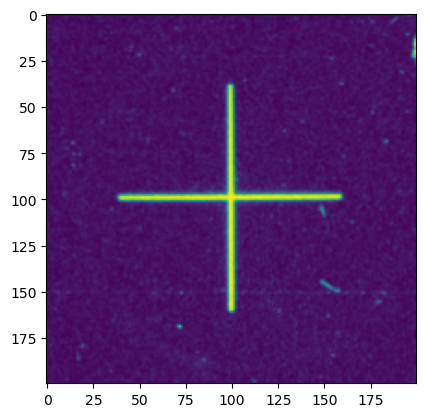

In [7]:
midside_template_file = 'input_data/fiducials/midside_fiducial.tif'
hipp.plot.plt.imshow(hipp.core.cv2.imread(midside_template_file,hipp.core.cv2.IMREAD_GRAYSCALE));

In [14]:
midside_template_high_res_file = hipp.utils.enhance_geotif_resolution(midside_template_file,
                                                                     factor=8)

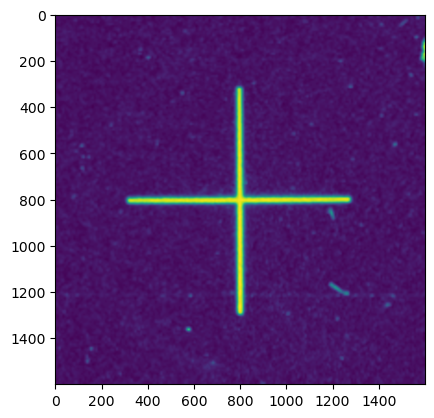

In [15]:
midside_template_high_res_file = 'input_data/fiducials/midside_fiducial_high_res.tif'
hipp.plot.plt.imshow(hipp.core.cv2.imread(midside_template_high_res_file,hipp.core.cv2.IMREAD_GRAYSCALE));

In [16]:
midside_template_high_res_zoomed_file = hipp.core.create_fiducial_template(midside_template_high_res_file,
                                                  output_directory = output_directory,
                                                  output_file_name='midside_fiducial_high_res_zoom_8.tif');

Launching server at http://localhost:39599


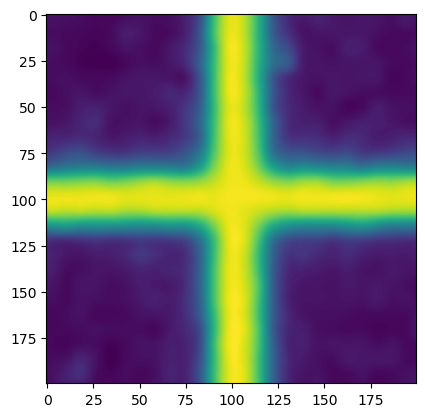

In [17]:
midside_template_high_res_zoomed_file = 'input_data/fiducials/midside_fiducial_high_res_zoom_8.tif'
hipp.plot.plt.imshow(hipp.core.cv2.imread(midside_template_high_res_zoomed_file,hipp.core.cv2.IMREAD_GRAYSCALE));

### Create Corner Fiducial Template
- Repeat the steps outlined above for corner fiducials.

In [18]:
corner_template_file = hipp.core.create_fiducial_template(image_file, 
                                                    output_directory = output_directory,
                                                    output_file_name='corner_fiducial.tif')

Launching server at http://localhost:36893


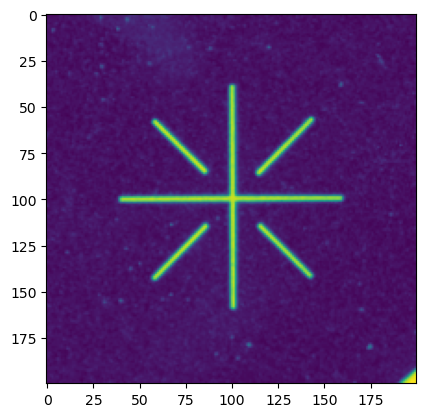

In [19]:
corner_template_file = 'input_data/fiducials/corner_fiducial.tif'
hipp.plot.plt.imshow(hipp.core.cv2.imread(corner_template_file,hipp.core.cv2.IMREAD_GRAYSCALE));

In [20]:
corner_template_high_res_file = hipp.utils.enhance_geotif_resolution(corner_template_file,
                                                                     factor=8)

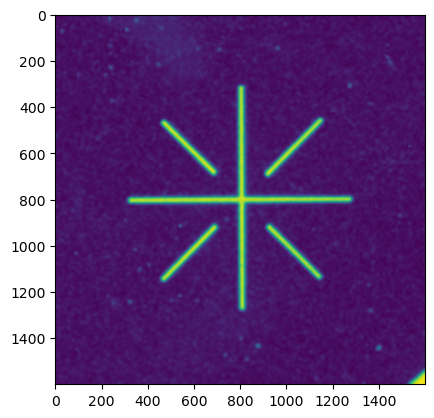

In [21]:
corner_template_high_res_file = 'input_data/fiducials/corner_fiducial_high_res.tif'
hipp.plot.plt.imshow(hipp.core.cv2.imread(corner_template_high_res_file,hipp.core.cv2.IMREAD_GRAYSCALE));

In [22]:
corner_template_high_res_zoomed_file = hipp.core.create_fiducial_template(corner_template_high_res_file,
                                                                    output_directory = output_directory,
                                                                    output_file_name='corner_fiducial_high_res_zoom_8.tif')

Launching server at http://localhost:44663


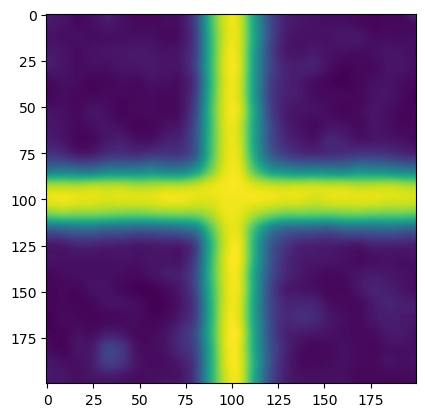

In [23]:
corner_template_high_res_zoomed_file = 'input_data/fiducials/corner_fiducial_high_res_zoom_8.tif'
hipp.plot.plt.imshow(hipp.core.cv2.imread(corner_template_high_res_zoomed_file,hipp.core.cv2.IMREAD_GRAYSCALE));

### Detect Fiducials
- Define folder with input images, along with high and low res fiducial markers.
- Run `hipp.core.iter_detect_fiducials()` to detect fiducial marker positions in each image.
- If `qc=True`, the routine outputs a cropped image window centered on detected positions under qc/fiducial_detection for quick visual inspection.

In [24]:
image_files_directory = 'input_data/raw_images/'

midside_template_file = 'input_data/fiducials/midside_fiducial.tif'
midside_template_high_res_zoomed_file = 'input_data/fiducials/midside_fiducial_high_res_zoom_8.tif'

corner_template_file = 'input_data/fiducials/corner_fiducial.tif'
corner_template_high_res_zoomed_file = 'input_data/fiducials/corner_fiducial_high_res_zoom_8.tif'

In [25]:
df_corner = hipp.batch.iter_detect_fiducials(
                                            image_files_directory = image_files_directory,
                                            template_file = corner_template_file,
                                            template_high_res_zoomed_file = corner_template_high_res_zoomed_file,
                                            corner_fiducials=True,
                                            qc=True)

In [26]:
df_midside = hipp.batch.iter_detect_fiducials(
                                            image_files_directory = image_files_directory,
                                            template_file = midside_template_file,
                                            template_high_res_zoomed_file = midside_template_high_res_zoomed_file,
                                            midside_fiducials=True,
                                            qc=True)

In [27]:
df_midside = hipp.core.eval_matches(df_midside)
df_corner = hipp.core.eval_matches(df_corner)

In [28]:
df_detected = hipp.core.merge_midside_df_corner_df(df_corner, df_midside)

### Prepare true fiducial marker coordinates
- Extract calibrated fiducial marker coordinate information from calibration report `Report_OSL_1785.pdf`, obtained via entering Camera Number, Lens Number, and Focal Length (printed on image frame) at https://fsapps.nwcg.gov/afm/cam/cam.php
- Extract scanning resolution from `info94Roll3.txt` obtained via https://arcticdata.io

In [29]:
# Fiducial Marker 5
midside_left_dist_pp_true_x_mm         = -111.998
midside_left_dist_pp_true_y_mm         = -0.004

# Fiducial Marker 7
midside_top_dist_pp_true_x_mm          = 0.014
midside_top_dist_pp_true_y_mm          = 111.993

# Fiducial Marker 6
midside_right_dist_pp_true_x_mm        = 112.004
midside_right_dist_pp_true_y_mm        = 0.000

# Fiducial Marker 8
midside_bottom_dist_pp_true_x_mm       = 0.000
midside_bottom_dist_pp_true_y_mm       = -112.002

# Fiducial Marker 3
corner_top_left_dist_pp_true_x_mm      = -109.989
corner_top_left_dist_pp_true_y_mm      = 109.995

# Fiducial Marker 2
corner_top_right_dist_pp_true_x_mm     = 110.010
corner_top_right_dist_pp_true_y_mm     = 109.999

# Fiducial Marker 4
corner_bottom_right_dist_pp_true_x_mm  = 109.998
corner_bottom_right_dist_pp_true_y_mm  = -110.002

# Fiducial Marker 1
corner_bottom_left_dist_pp_true_x_mm   = -109.990
corner_bottom_left_dist_pp_true_y_mm   = -110.002

In [30]:
fiducial_coordinates_true_mm = [(midside_left_dist_pp_true_x_mm, midside_left_dist_pp_true_y_mm),
                                (midside_top_dist_pp_true_x_mm, midside_top_dist_pp_true_y_mm),
                                (midside_right_dist_pp_true_x_mm, midside_right_dist_pp_true_y_mm),
                                (midside_bottom_dist_pp_true_x_mm, midside_bottom_dist_pp_true_y_mm),
                                (corner_top_left_dist_pp_true_x_mm, corner_top_left_dist_pp_true_y_mm),
                                (corner_top_right_dist_pp_true_x_mm, corner_top_right_dist_pp_true_y_mm),
                                (corner_bottom_right_dist_pp_true_x_mm, corner_bottom_right_dist_pp_true_y_mm),
                                (corner_bottom_left_dist_pp_true_x_mm, corner_bottom_left_dist_pp_true_y_mm)]

### Image restitution
- Default options shown below.
- Set `transform_image=False`, `crop_image=False` to skip image processing and only compute transform qc products.
- Set `transform_image=False` to skip image transform and crop images about detected principal point.
- Set `crop_image=False` to transfor image without cropping.
- Recommended image interpolation orders (modes) are `3 (bi-cubic)` or `1 (bi-linear)`.

Image restitution qc plots in qc/restitution/


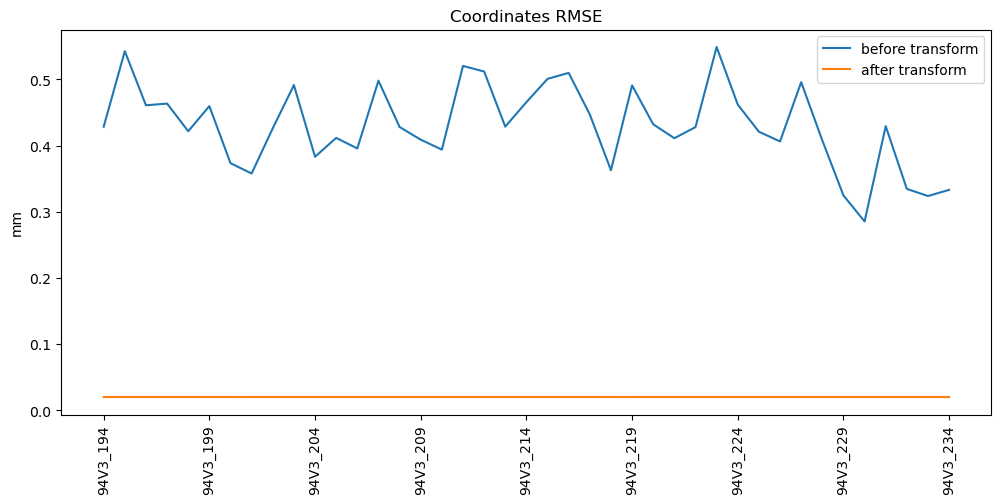

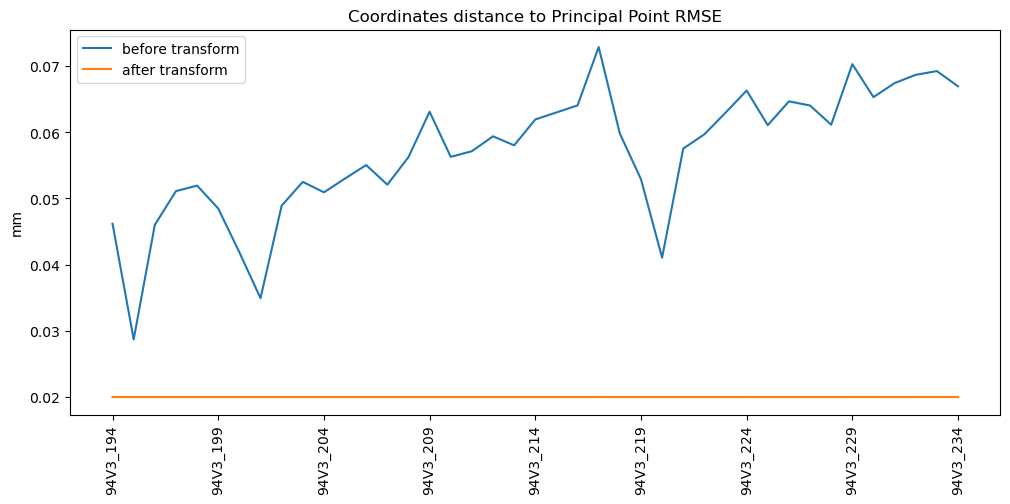

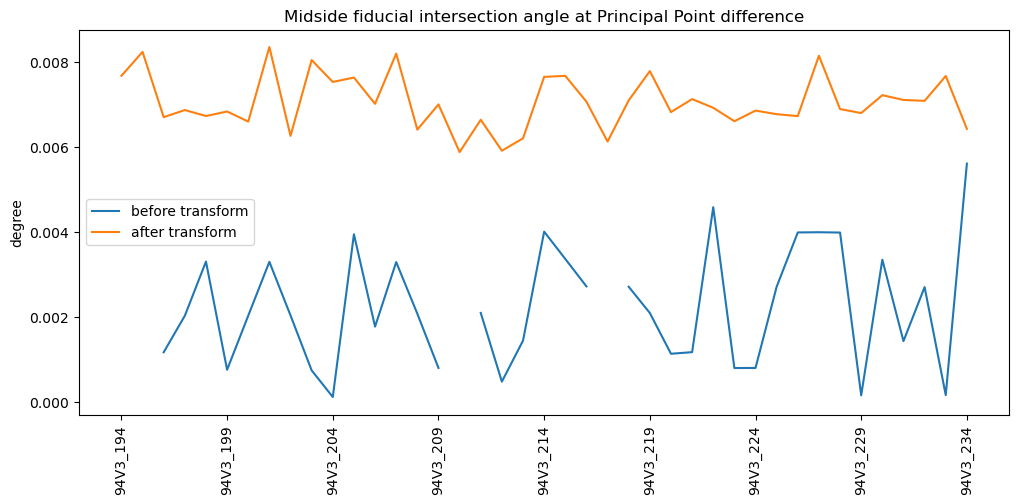

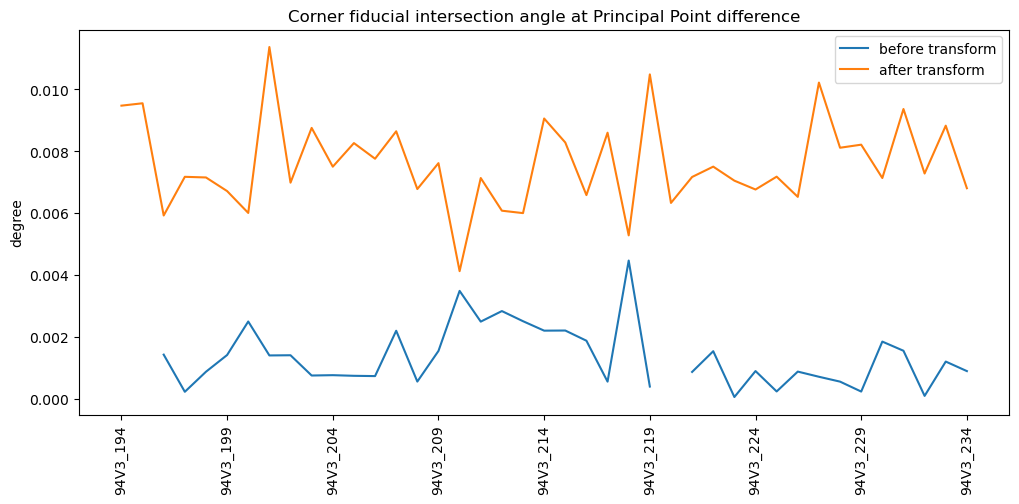

In [32]:
hipp.batch.image_restitution(df_detected,
                             fiducial_coordinates_true_mm,
                             scanning_resolution_mm=0.02,
                             transform_coords=True,
                             transform_image=False,
                             crop_image=False,
                             image_square_dim=10800,
                             interpolation_order=3,
                             qc=True)